In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
data=pd.read_csv('MPG_Customer_Churn_Dataset.csv')

In [66]:
data.sample(10)

,Customer_ID,Customer_Type,City,Product_Category,Purchase_Frequency,Total_Amount,Avg_Order_Value,Last_Purchase_Days,Credit_Days,Payment_Mode,Orders_Last_6_Months,Complaint_Count,Years_As_Customer,Churn,Secondary_Contact,GST_Verification_Date,Remarks
4680,C4681,Retailer,Gurgaon,Bearings,1,92947,46474,1,30,Online,2,0,0,Yes,NaN,NaN,NaN
4611,C4612,Contractor,Kanpur,Lubricants,1,41124,20562,196,45,UPI,2,5,8,Yes,NaN,NaN,NaN
747,C0748,Dealer,Faridabad,Safety Equipment,6,367549,45944,235,15,Credit,8,1,13,No,NaN,NaN,NaN
4764,C4765,Dealer,Faridabad,Bearings,9,340731,48676,46,0,Cash,7,0,10,No,NaN,NaN,NaN
4080,C4081,Contractor,Faridabad,Bearings,5,92328,30776,278,30,Cash,3,0,7,No,NaN,NaN,NaN
3194,C3195,Dealer,Kanpur,Tools,24,500295,21752,253,15,Credit,23,3,3,Yes,NaN,NaN,NaN
3868,C3869,Industry,Agra,Tools,14,362656,24177,341,0,Cash,15,2,11,No,NaN,2021-01-16,NaN
2866,C2867,Dealer,Delhi,Fasteners,8,321813,35757,150,60,Bank Transfer,9,2,15,No,NaN,NaN,NaN
3964,C3965,Dealer,Gurgaon,Lubricants,10,526041,47822,112,45,Bank Transfer,11,0,0,No,NaN,NaN,NaN
404,C0405,Contractor,Noida,Lubricants,8,136381,19483,106,0,UPI,7,0,8,No,9.121863e+09,NaN,Legacy


In [67]:
# Data Cleaning
# Exploratory Data Analysis (EDA)
# Data Preprocessing & Feature Engineering
# Model Building
# Model Evaluation
# Model Improvement
# Website 
# Deployment

###  1. Data Cleaning

In [68]:
data.shape

(5000, 17)

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            5000 non-null   object 
 1   Customer_Type          5000 non-null   object 
 2   City                   5000 non-null   object 
 3   Product_Category       5000 non-null   object 
 4   Purchase_Frequency     5000 non-null   int64  
 5   Total_Amount           5000 non-null   int64  
 6   Avg_Order_Value        5000 non-null   int64  
 7   Last_Purchase_Days     5000 non-null   int64  
 8   Credit_Days            5000 non-null   int64  
 9   Payment_Mode           5000 non-null   object 
 10  Orders_Last_6_Months   5000 non-null   int64  
 11  Complaint_Count        5000 non-null   int64  
 12  Years_As_Customer      5000 non-null   int64  
 13  Churn                  5000 non-null   object 
 14  Secondary_Contact      610 non-null    float64
 15  GST_

In [70]:
data.isnull().sum()


Customer_ID                 0
Customer_Type               0
City                        0
Product_Category            0
Purchase_Frequency          0
Total_Amount                0
Avg_Order_Value             0
Last_Purchase_Days          0
Credit_Days                 0
Payment_Mode                0
Orders_Last_6_Months        0
Complaint_Count             0
Years_As_Customer           0
Churn                       0
Secondary_Contact        4390
GST_Verification_Date    4664
Remarks                  4755
dtype: int64

In [71]:
data.duplicated().sum()

np.int64(0)

In [72]:
data=data.drop(columns=['Customer_ID','Secondary_Contact','GST_Verification_Date','Remarks'])

In [73]:
data.sample(5)

,Customer_Type,City,Product_Category,Purchase_Frequency,Total_Amount,Avg_Order_Value,Last_Purchase_Days,Credit_Days,Payment_Mode,Orders_Last_6_Months,Complaint_Count,Years_As_Customer,Churn
1029,Dealer,Chandigarh,Industrial Supplies,17,697910,38773,8,15,Bank Transfer,18,3,0,No
410,Dealer,Gurgaon,Industrial Supplies,8,130749,13075,196,45,Credit,10,0,13,No
2547,Industry,Jaipur,Lubricants,18,565659,33274,238,60,Credit,17,7,12,Yes
3575,Dealer,Gurgaon,Industrial Supplies,23,454232,20647,237,0,Online,22,5,9,No
3416,Retailer,Ghaziabad,Industrial Supplies,18,819374,40969,35,15,UPI,20,0,3,No


In [74]:
data['Churn'].value_counts()

Churn
No     3432
Yes    1568
Name: count, dtype: int64

### 2. Exploratory Data Analysis (EDA)

<Axes: xlabel='Churn', ylabel='count'>

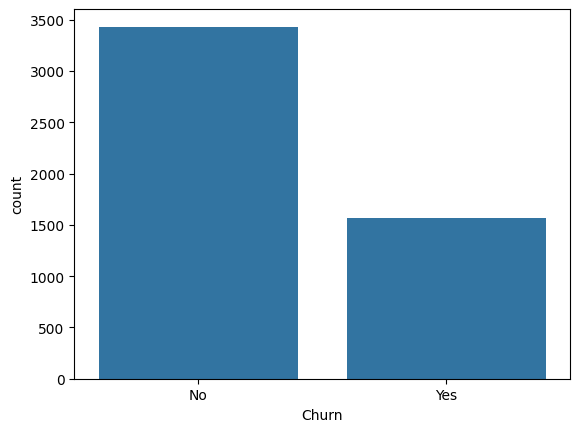

In [75]:
sns.countplot(x='Churn', data=data)

<Axes: xlabel='Customer_Type', ylabel='count'>

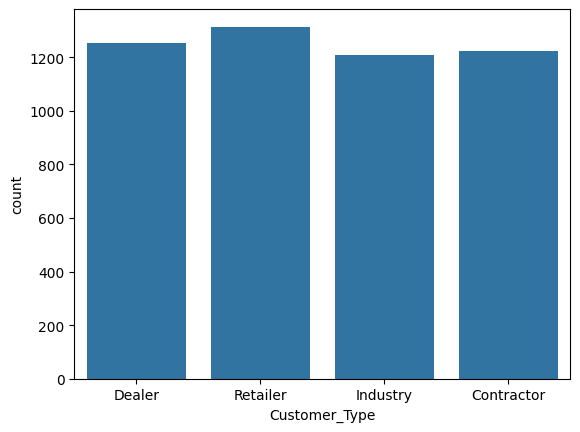

In [76]:
sns.countplot(x='Customer_Type', data=data)

<Axes: xlabel='City'>

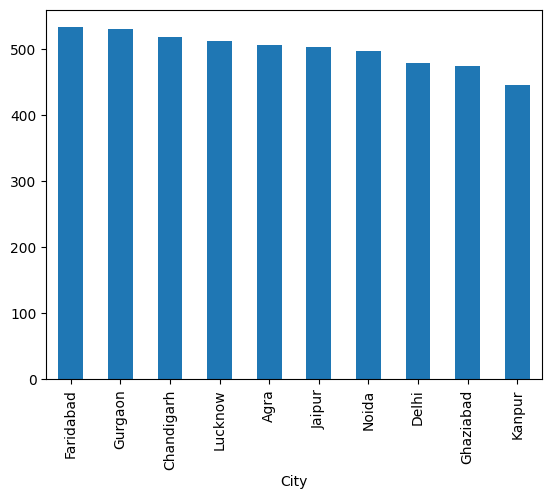

In [77]:
data['City'].value_counts().plot(kind='bar')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Industrial Supplies'),
  Text(1, 0, 'Fasteners'),
  Text(2, 0, 'Bearings'),
  Text(3, 0, 'Tools'),
  Text(4, 0, 'Chemicals'),
  Text(5, 0, 'Lubricants'),
  Text(6, 0, 'Safety Equipment'),
  Text(7, 0, 'Electrical')])

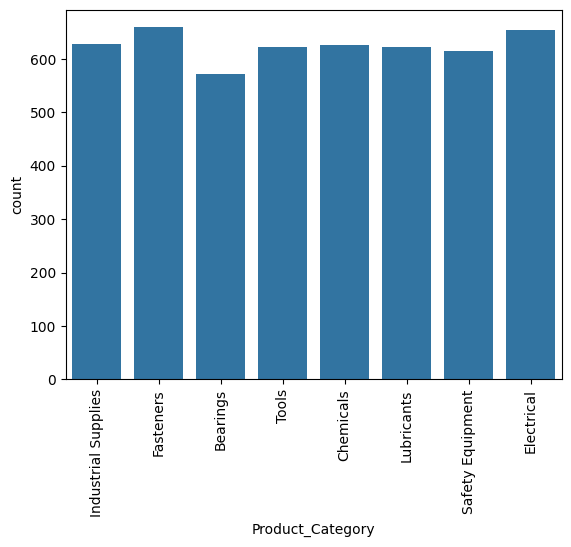

In [78]:
sns.countplot(x='Product_Category', data=data)
plt.xticks(rotation=90)

<Axes: xlabel='Purchase_Frequency', ylabel='Count'>

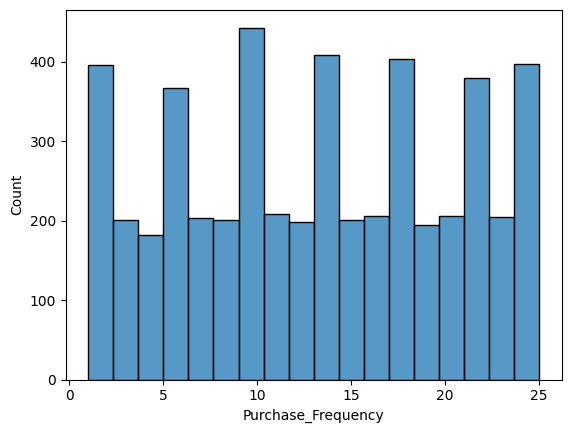

In [79]:
sns.histplot(data['Purchase_Frequency'])

<Axes: ylabel='Total_Amount'>

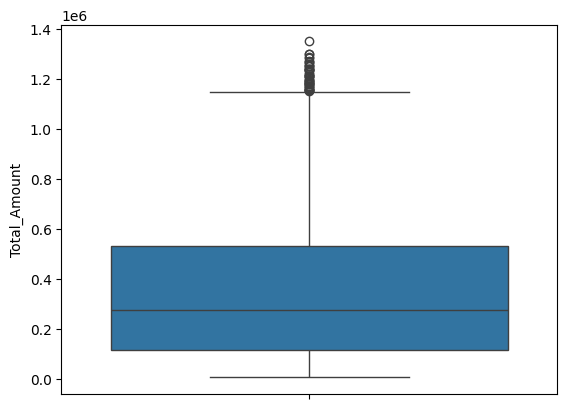

In [80]:
sns.boxplot(data['Total_Amount'])

<Axes: xlabel='Complaint_Count', ylabel='count'>

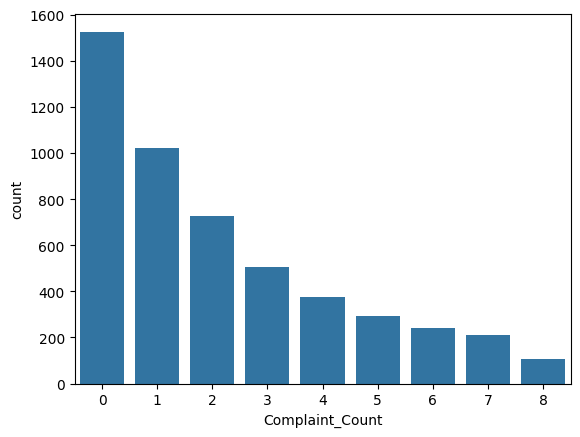

In [81]:
sns.countplot(x='Complaint_Count', data=data)

<Axes: >

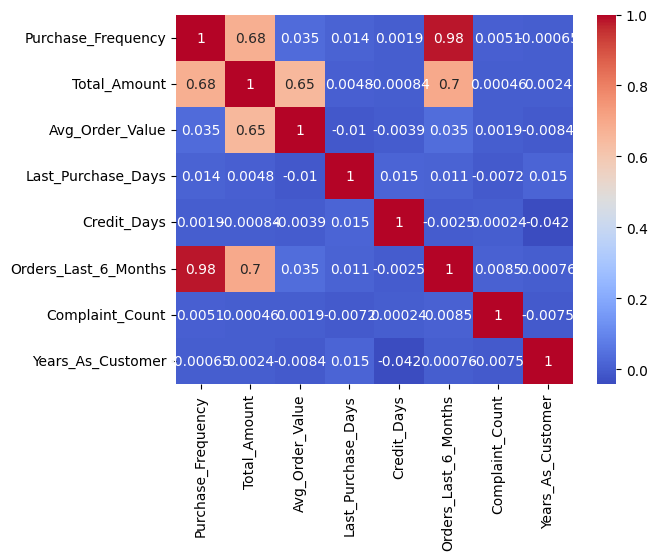

In [82]:
sns.heatmap(data.corr(numeric_only=True),annot=True, cmap='coolwarm')

### 3. Data Preprocessing & Feature Engineering

In [83]:
data['Churn'] = data['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [84]:
X = data.drop(columns=['Churn'])
y = data['Churn']

In [85]:
X.head()

,Customer_Type,City,Product_Category,Purchase_Frequency,Total_Amount,Avg_Order_Value,Last_Purchase_Days,Credit_Days,Payment_Mode,Orders_Last_6_Months,Complaint_Count,Years_As_Customer
0,Dealer,Chandigarh,Industrial Supplies,21,227415,11969,141,0,Cash,19,0,0
1,Retailer,Jaipur,Fasteners,3,77819,38910,259,60,Online,2,2,7
2,Dealer,Noida,Industrial Supplies,1,17624,17624,175,0,Online,0,0,13
3,Retailer,Noida,Bearings,12,531033,37931,23,90,Bank Transfer,14,3,8
4,Industry,Noida,Tools,12,647437,46246,361,0,UPI,14,0,6


In [86]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: Churn, dtype: int64

In [87]:
# Identify Numerical and Categorical Columns
cat_cols = X.select_dtypes(include='object').columns # for categorical columns

num_cols = X.select_dtypes(exclude='object').columns # for numerical columns

In [88]:
cat_cols, num_cols

(Index(['Customer_Type', 'City', 'Product_Category', 'Payment_Mode'], dtype='object'),
 Index(['Purchase_Frequency', 'Total_Amount', 'Avg_Order_Value',
        'Last_Purchase_Days', 'Credit_Days', 'Orders_Last_6_Months',
        'Complaint_Count', 'Years_As_Customer'],
       dtype='object'))

In [89]:
# Replace missing values with the median.
from sklearn.impute import SimpleImputer
# for numerical columns 
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])
# for categorical columns
imputer = SimpleImputer(strategy='most_frequent')   
X[cat_cols] = imputer.fit_transform(X[cat_cols])


In [90]:
# Encode Categorical Features
# Using One-Hot Encoding for categorical features

X = pd.get_dummies(X,columns=['Customer_Type','City','Product_Category','Payment_Mode'], drop_first=True)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)


In [91]:
from sklearn.pipeline import Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])


In [92]:
from sklearn.preprocessing import OneHotEncoder

In [93]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])    

### 4. Model Building & Evaluation

In [94]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
# Stratify keeps the proportion of churned and non-churned customers similar in both the training and
# test sets, which is especially helpful if the classes are imbalanced.


In [95]:
from sklearn.ensemble import RandomForestClassifier

model = model = RandomForestClassifier(random_state=42)

In [96]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [97]:
y_pred = model.predict(X_test)

In [98]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [99]:
accuracy = model.score(X_test,y_test)
accuracy

0.865

In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       686
           1       0.80      0.76      0.78       314

    accuracy                           0.86      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.86      0.86      0.86      1000



In [101]:
y_train.value_counts()

Churn
0    2746
1    1254
Name: count, dtype: int64

In [102]:
#from imblearn.over_sampling import SMOTE

In [103]:
#smote = SMOTE(random_state=42)

In [104]:
#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
#print(y_train_smote.shape)
#print(y_train_smote.value_counts())

In [105]:
# Scaling the features using StandardScaler to improve model performance and convergence speed 
# for logistic regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier


In [107]:
# dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [108]:
def train_classifiers(X_train, y_train, X_test, y_test,X_train_scaled, X_test_scaled, models):
    results = {}
    for name, model in models.items():
        # Use scaled data only for Logistic Regression
        if name == "Logistic Regression":
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results[name] = {
             "Accuracy": accuracy,
             "Precision": precision,
             "Recall": recall,
             "F1 Score": f1
        }
    return results




In [109]:
trained_results = train_classifiers(X_train, y_train, X_test, y_test,X_train_scaled, X_test_scaled,models)

In [110]:
trained_results

{'Decision Tree': {'Accuracy': 0.858,
  'Precision': 0.7774193548387097,
  'Recall': 0.767515923566879,
  'F1 Score': 0.7724358974358975},
 'Random Forest': {'Accuracy': 0.865,
  'Precision': 0.7993311036789298,
  'Recall': 0.7611464968152867,
  'F1 Score': 0.7797716150081566},
 'XGBoost': {'Accuracy': 0.863,
  'Precision': 0.764179104477612,
  'Recall': 0.8152866242038217,
  'F1 Score': 0.7889060092449923},
 'Logistic Regression': {'Accuracy': 0.798,
  'Precision': 0.7333333333333333,
  'Recall': 0.5605095541401274,
  'F1 Score': 0.6353790613718412},
 'Gradient Boosting': {'Accuracy': 0.879,
  'Precision': 0.7615176151761518,
  'Recall': 0.8949044585987261,
  'F1 Score': 0.8228404099560761}}

In [111]:
# Converting Results into a DataFrame & Visualizing Performance

,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.858,0.777419,0.767516,0.772436
Random Forest,0.865,0.799331,0.761146,0.779772
XGBoost,0.863,0.764179,0.815287,0.788906
Logistic Regression,0.798,0.733333,0.560510,0.635379
Gradient Boosting,0.879,0.761518,0.894904,0.822840


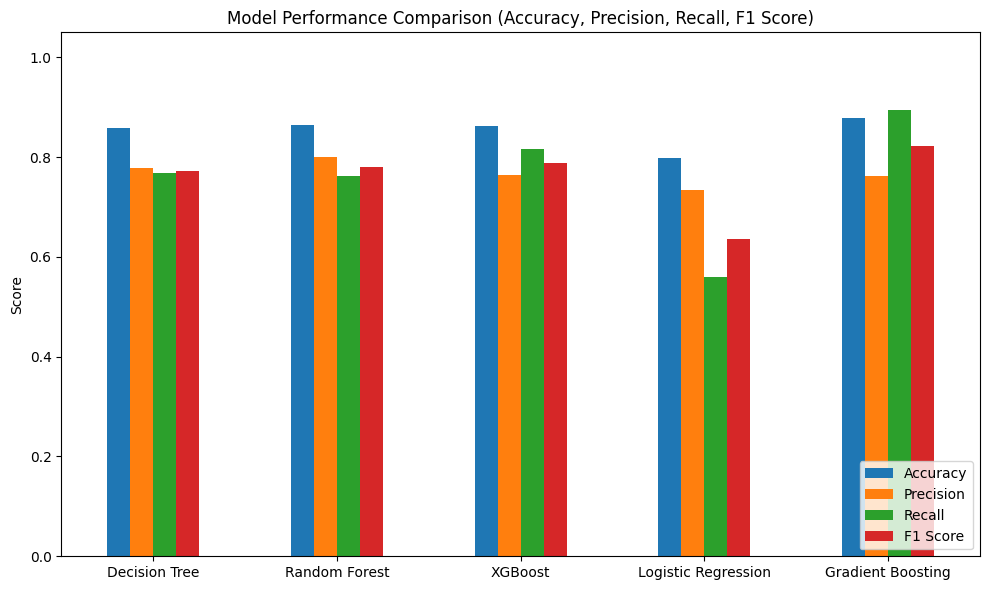

In [112]:
# Convert results dictionary to a clean pandas DataFrame
results_df = pd.DataFrame(trained_results).T
display(results_df)

# Plot Model Comparison Bar Chart
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Comparison (Accuracy, Precision, Recall, F1 Score)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

=== Classification Report for Gradient Boosting ===
              precision    recall  f1-score   support

    No Churn       0.95      0.87      0.91       686
       Churn       0.76      0.89      0.82       314

    accuracy                           0.88      1000
   macro avg       0.85      0.88      0.87      1000
weighted avg       0.89      0.88      0.88      1000



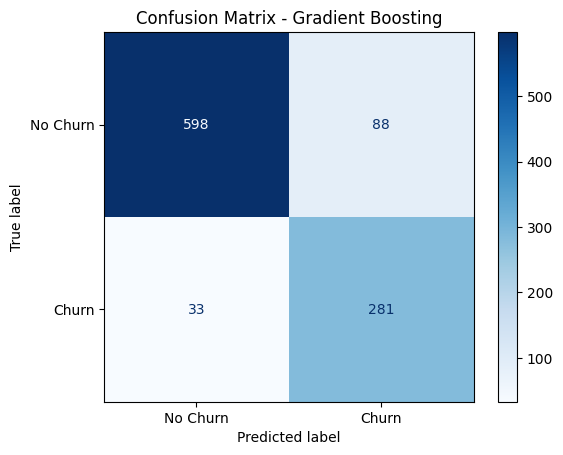

In [113]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#  the best model (Gradient Boosting)
best_model_name = "Gradient Boosting"
best_model = models[best_model_name]

# Predict on test set
y_pred_best = best_model.predict(X_test)

#  Detailed Classification Report
print(f"=== Classification Report for {best_model_name} ===")
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.grid(False)
plt.show()

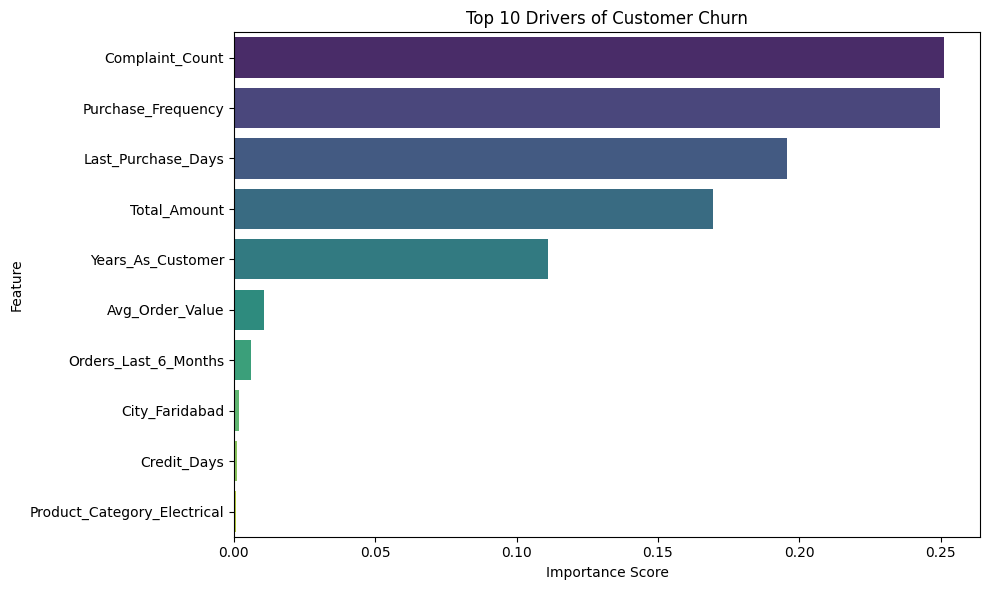

In [114]:
# Extracting Feature Importances from Gradient Boosting
importances = best_model.feature_importances_
feature_names = X_train.columns

# Creating Feature Importance DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), hue='Feature', palette='viridis')
plt.title("Top 10 Drivers of Customer Churn")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [115]:
import joblib

# Save the trained best model
joblib.dump(best_model, 'best_churn_model.pkl')
print("Model saved successfully as 'best_churn_model.pkl'!")

Model saved successfully as 'best_churn_model.pkl'!


In [116]:
# Function to predict churn for a single customer
def predict_churn(customer_data_df):
    model = joblib.load('best_churn_model.pkl')
    prediction = model.predict(customer_data_df)[0]
    probability = model.predict_proba(customer_data_df)[0][1]
    
    result = "Churn (High Risk)" if prediction == 1 else "No Churn (Low Risk)"
    print(f"Prediction: {result}")
    print(f"Churn Probability: {probability * 100:.2f}%")

# Example: Predict using the first row of test data
sample_input = X_test.iloc[[0]]
predict_churn(sample_input)

Prediction: No Churn (Low Risk)
Churn Probability: 1.46%


In [117]:
print(list(model.feature_names_in_))

['Purchase_Frequency', 'Total_Amount', 'Avg_Order_Value', 'Last_Purchase_Days', 'Credit_Days', 'Orders_Last_6_Months', 'Complaint_Count', 'Years_As_Customer', 'Customer_Type_Dealer', 'Customer_Type_Industry', 'Customer_Type_Retailer', 'City_Chandigarh', 'City_Delhi', 'City_Faridabad', 'City_Ghaziabad', 'City_Gurgaon', 'City_Jaipur', 'City_Kanpur', 'City_Lucknow', 'City_Noida', 'Product_Category_Chemicals', 'Product_Category_Electrical', 'Product_Category_Fasteners', 'Product_Category_Industrial Supplies', 'Product_Category_Lubricants', 'Product_Category_Safety Equipment', 'Product_Category_Tools', 'Payment_Mode_Cash', 'Payment_Mode_Credit', 'Payment_Mode_Online', 'Payment_Mode_UPI']


In [118]:
# high_risk_customer = pd.DataFrame([{
#     'Purchase_Frequency': 2,
#     'Total_Amount': 15000,
#     'Avg_Order_Value': 7500,
#     'Last_Purchase_Days': 280,
#     'Credit_Days': 90,
#     'Orders_Last_6_Months': 1,
#     'Complaint_Count': 6,
#     'Years_As_Customer': 1,

#     'Customer_Type_Dealer': 0,
#     'Customer_Type_Industry': 0,
#     'Customer_Type_Retailer': 1,

#     'City_Chandigarh': 0,
#     'City_Delhi': 1,
#     'City_Faridabad': 0,
#     'City_Ghaziabad': 0,
#     'City_Gurgaon': 0,
#     'City_Jaipur': 0,
#     'City_Kanpur': 0,
#     'City_Lucknow': 0,
#     'City_Noida': 0,

#     'Product_Category_Chemicals': 0,
#     'Product_Category_Electrical': 0,
#     'Product_Category_Fasteners': 0,
#     'Product_Category_Industrial Supplies': 0,
#     'Product_Category_Lubricants': 0,
#     'Product_Category_Safety Equipment': 0,
#     'Product_Category_Tools': 0,

#     'Payment_Mode_Cash': 0,
#     'Payment_Mode_Credit': 1,
#     'Payment_Mode_Online': 0,
#     'Payment_Mode_UPI': 0
# }])

# low_risk_customer = pd.DataFrame([{
#     'Purchase_Frequency': 25,
#     'Total_Amount': 650000,
#     'Avg_Order_Value': 26000,
#     'Last_Purchase_Days': 10,
#     'Credit_Days': 15,
#     'Orders_Last_6_Months': 22,
#     'Complaint_Count': 0,
#     'Years_As_Customer': 8,

#     'Customer_Type_Dealer': 1,
#     'Customer_Type_Industry': 0,
#     'Customer_Type_Retailer': 0,

#     'City_Chandigarh': 1,
#     'City_Delhi': 0,
#     'City_Faridabad': 0,
#     'City_Ghaziabad': 0,
#     'City_Gurgaon': 0,
#     'City_Jaipur': 0,
#     'City_Kanpur': 0,
#     'City_Lucknow': 0,
#     'City_Noida': 0,

#     'Product_Category_Chemicals': 0,
#     'Product_Category_Electrical': 0,
#     'Product_Category_Fasteners': 0,
#     'Product_Category_Industrial Supplies': 0,
#     'Product_Category_Lubricants': 0,
#     'Product_Category_Safety Equipment': 0,
#     'Product_Category_Tools': 1,

#     'Payment_Mode_Cash': 1,
#     'Payment_Mode_Credit': 0,
#     'Payment_Mode_Online': 0,
#     'Payment_Mode_UPI': 0
# }])

# print("=== High Risk Customer Test ===")
# predict_churn(high_risk_customer)
# print("\n=== Low Risk Customer Test ===")
# predict_churn(low_risk_customer)




# Output:
# === High Risk Customer Test ===
# Prediction: Churn (High Risk)
# Churn Probability: 99.14%

# === Low Risk Customer Test ===
# Prediction: No Churn (Low Risk)
# Churn Probability: 0.37%

In [119]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb_model = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# Update and save final tuned model
best_tuned_model = grid_search.best_estimator_
joblib.dump(best_tuned_model, 'best_churn_model.pkl')
print("Updated 'best_churn_model.pkl' with fine-tuned model!")

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-Validation F1-Score: 0.8103
Updated 'best_churn_model.pkl' with fine-tuned model!
